### This testing is done by using the authentic Odia & Google Translated german corpus with facebook/nllb-200-distilled-600M.

✅ Steps followed for this test:

    👉 The odia sentences in authentic_odia_corpus.txt are translated using Google Translate. We got the first german corpus file: authentic_german_corpus.txt.

    👉 check_num_of_lines.ipynb file is executed to confirm the number of instances in both odia corpus & german corpus are same or not. & we got the same number of instances in both files.

    👉 final_data_instance_creation.ipynb file is executed to generate the final data instance (complete_corpus_poc.jsonl).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install torch transformers datasets sacrebleu accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 10.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink

In [ ]:
import json
import torch
from datasets import load_dataset, Dataset, DatasetDict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sacrebleu
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq, pipeline

# Configuration and Data Preparation

This code block sets up all parameters, loads your dataset, and splits it into the crucial train, validation, and test sets.

In [ ]:
# --- 1. CONFIGURATION ---

# --- File and Model Configuration ---
CORPUS_FILE = "/content/drive/MyDrive/Thesis/test/data/transformed/complete_corpus.jsonl"
MODEL_NAME = "facebook/nllb-200-distilled-600M"
OUTPUT_DIR = "/content/drive/MyDrive/Thesis/test/nllb-finetuned-odia-german-results_1"
FINAL_MODEL_PATH = "/content/drive/MyDrive/Thesis/test/final-odia-german-translator_test_1"

# --- Language and Split Configuration ---
SOURCE_LANG_CODE = "ory_Orya"  # Odia
TARGET_LANG_CODE = "deu_Latn"  # German
SOURCE_FIELD = "sentence_ory_Orya" # As defined in your JSONL
TARGET_FIELD = "sentence_deu_Latn" # As defined in your JSONL

TEST_SET_SIZE = 0.10   # 10% of the data will be for the final, unseen test set
VALIDATION_SET_SIZE = 0.10 # 10% of the remaining data for validation

# --- 2. LOAD AND SPLIT THE DATASET ---

print("Loading the full dataset from JSONL file...")

# --- Manually load the JSONL file into a list of dictionaries ---
data_list = []
with open(CORPUS_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        data_list.append(json.loads(line))

# --- Create a pandas DataFrame ---
df = pd.DataFrame(data_list)

# --- Convert the DataFrame into a Hugging Face Dataset object ---
# This bypasses the caching issue.
full_dataset = Dataset.from_pandas(df)

print("Dataset loaded successfully.")

# --- Shuffle the dataset before splitting ---
full_dataset = full_dataset.shuffle(seed=42)

# --- Create the Test Split ---
# This first split separates the final, unseen test set.
train_valid_split = full_dataset.train_test_split(test_size=TEST_SET_SIZE, seed=42)
test_dataset = train_valid_split['test']

# --- Create the Train and Validation Splits ---
# The remaining data is split again to create the training and validation sets.
train_val_split = train_valid_split['train'].train_test_split(test_size=VALIDATION_SET_SIZE / (1 - TEST_SET_SIZE), seed=42)
train_dataset = train_val_split['train']
validation_dataset = train_val_split['test']

# Combine into a single DatasetDict for convenience
split_datasets = DatasetDict({
    'train': train_dataset,
    'validation': validation_dataset,
    'test': test_dataset
})

print("\nDataset successfully split:")
print(f"Training set size: {len(split_datasets['train'])}")
print(f"Validation set size: {len(split_datasets['validation'])}")
print(f"Test set size: {len(split_datasets['test'])}")

# --- 3. PREPARE TOKENIZER AND PREPROCESSING FUNCTION ---

print("\nLoading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, src_lang=SOURCE_LANG_CODE, tgt_lang=TARGET_LANG_CODE)

def preprocess_function(examples):
    """Tokenizes source and target sentences from the flat JSON structure."""

    # Access the lists of sentences directly from the batch columns
    inputs = examples[SOURCE_FIELD]
    targets = examples[TARGET_FIELD]

    model_inputs = tokenizer(inputs, max_length=128, truncation=True)

    with tokenizer.as_target_tokenizer():
        labels = tokenizer(targets, max_length=128, truncation=True)

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

print("Tokenizing all dataset splits...")
# Note: The `remove_columns` is correct because we are removing the original columns from the DataFrame
tokenized_datasets = split_datasets.map(preprocess_function, batched=True, batch_size=16, remove_columns=split_datasets['train'].column_names)
print("Tokenization complete.")

Loading the full dataset from JSONL file...
Dataset loaded successfully.

Dataset successfully split:
Training set size: 5041
Validation set size: 631
Test set size: 631

Loading tokenizer...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

...

Map:   0%|          | 0/5041 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3959: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/631 [00:00<?, ? examples/s]

Map:   0%|          | 0/631 [00:00<?, ? examples/s]

Tokenization complete.


# Baseline Evaluation

This code block evaluates the original NLLB model on the `test` set before any fine-tuning happens.

In [ ]:
# --- 4. BASELINE EVALUATION ---
print("\n--- Evaluating Baseline Model (Before Fine-Tuning) ---")

# Load the original, pre-trained model for baseline measurement
base_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
device = 0 if torch.cuda.is_available() else -1

# Use the simpler pipeline API for straightforward inference
translator = pipeline(
    'translation',
    model=base_model,
    tokenizer=tokenizer,
    src_lang=SOURCE_LANG_CODE,
    tgt_lang=TARGET_LANG_CODE,
    device=device
)

# Get source sentences and true target translations from the test set
test_odia_sentences = [ex[SOURCE_FIELD] for ex in split_datasets['test']]
test_german_references = [[ex[TARGET_FIELD] for ex in split_datasets['test']]] # Sacrebleu expects a list of lists

# Generate predictions
print(f"Generating translations for {len(test_odia_sentences)} test sentences...")
baseline_predictions = translator(test_odia_sentences, batch_size=16, max_length=1200)
decoded_baseline_preds = [pred['translation_text'] for pred in baseline_predictions]

# Calculate BLEU score
metric = sacrebleu.BLEU()
baseline_bleu = metric.corpus_score(decoded_baseline_preds, test_german_references)

print("\n--- Baseline Performance ---")
print(f"BLEU Score of the original NLLB model: {baseline_bleu.score:.4f}")

# Store the result for final comparison
baseline_score = baseline_bleu.score


--- Evaluating Baseline Model (Before Fine-Tuning) ---


Device set to use cuda:0


Generating translations for 631 test sentences...



--- Baseline Performance ---
BLEU Score of the original NLLB model: 5.0945


# Fine-Tuning

This code block sets up and runs the actual fine-tuning process.

In [ ]:
# --- 5. FINE-TUNING THE MODEL ---
print("\n--- Starting Fine-Tuning Process ---")

# The model object is already loaded as 'base_model', we can reuse it for training.
model = base_model

# Data collator will create batches of data for training
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

def compute_metrics(eval_preds):
  """Computes BLEU, chrF, and TER scores during evaluation."""
  preds, labels = eval_preds
  if isinstance(preds, tuple):
    preds = preds[0]

  decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

  labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
  decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

  # Sacrebleu expects labels to be in a list of lists for BLEU calculation
  decoded_labels_for_bleu = [[label] for label in decoded_labels]

  # --- Calculate BLEU ---
  bleu_metric = sacrebleu.BLEU()
  bleu_result = bleu_metric.corpus_score(decoded_preds, decoded_labels_for_bleu)

  # --- Calculate chrF ---
  # Higher is better
  chrf_metric = sacrebleu.CHRF(word_order=2) # word_order=2 is recommended
  chrf_result = chrf_metric.corpus_score(decoded_preds, decoded_labels_for_bleu)

  # --- Calculate TER ---
  # Lower is better
  ter_metric = sacrebleu.TER()
  ter_result = ter_metric.corpus_score(decoded_preds, decoded_labels_for_bleu)

  # Return all metrics in a dictionary
  # The trainer will log all of these
  return {
      "bleu": bleu_result.score,
      "chrf": chrf_result.score,
      "ter": ter_result.score
  }

# Define training arguments
training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=3,
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),
    load_best_model_at_end=True,
    metric_for_best_model="bleu",
    greater_is_better=True,
    optim="adafactor",
    report_to="wandb"
)

# Initialize the Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Start training!
trainer.train()

# Save the final, best-performing model
print("Saving the fine-tuned model...")
trainer.save_model(FINAL_MODEL_PATH)
print(f"Model saved to '{FINAL_MODEL_PATH}'")


--- Starting Fine-Tuning Process ---


<ipython-input-7-3028933149>:72: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: abhinandan198 (abhinandan198-iu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.58.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Epoch,Training Loss,Validation Loss,Bleu,Chrf,Ter
1,No log,0.984860,0.000000,0.000000,0.000000
2,1.155200,0.960227,0.000000,0.000000,0.000000
3,1.155200,0.956497,0.000000,0.000000,0.000000


/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:3465: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Saving the fine-tuned model...
Model saved to '/content/drive/MyDrive/Thesis/test/final-odia-german-translator_test'


# Final Evaluation and Comparison

This code block evaluates newly fine-tuned model on the same test set and presents a clear comparison with the baseline.

In [ ]:
# --- 6. FINAL EVALUATION AND COMPARISON ---
print("\n--- Evaluating Fine-Tuned Model ---")

# The trainer.model now holds the best fine-tuned model weights
finetuned_model = trainer.model

# Re-initialize the pipeline with the fine-tuned model
translator_finetuned = pipeline(
    'translation',
    model=finetuned_model,
    tokenizer=tokenizer,
    src_lang=SOURCE_LANG_CODE,
    tgt_lang=TARGET_LANG_CODE,
    device=device
)

# Generate predictions with the new model
print(f"Generating translations for {len(test_odia_sentences)} test sentences with the fine-tuned model...")
finetuned_predictions = translator_finetuned(test_odia_sentences, batch_size=16, max_length=128)
decoded_finetuned_preds = [pred['translation_text'] for pred in finetuned_predictions]

# Calculate BLEU score
finetuned_bleu = metric.corpus_score(decoded_finetuned_preds, test_german_references)

print("\n--- Final Performance Comparison ---")
print("This result is the core quantitative finding for your thesis.")
print("="*50)
print(f"Baseline NLLB Model BLEU Score:      {baseline_score:.4f}")
print(f"Fine-Tuned Model BLEU Score:         {finetuned_bleu.score:.4f}")
print("="*50)
improvement = finetuned_bleu.score - baseline_score
print(f"Improvement in BLEU score:           +{improvement:.4f}")
print(f"Percentage Improvement:              +{(improvement/baseline_score)*100:.2f}%")
print("="*50)

Device set to use cuda:0



--- Evaluating Fine-Tuned Model ---
Generating translations for 631 test sentences with the fine-tuned model...


Your input_length: 121 is bigger than 0.9 * max_length: 128. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)



--- Final Performance Comparison ---
This result is the core quantitative finding for your thesis.
Baseline NLLB Model BLEU Score:      5.0945
Fine-Tuned Model BLEU Score:         24.9344
Improvement in BLEU score:           +19.8399
Percentage Improvement:              +389.44%


## Visualization 1: Final Performance Bar Chart

To compare the final scores of the baseline vs. fine-tuned model.

In [ ]:
baseline_results = {
    'bleu': baseline_bleu.score,
    'chrf': sacrebleu.CHRF(word_order=2).corpus_score(decoded_baseline_preds, test_german_references).score,
    'ter': sacrebleu.TER().corpus_score(decoded_baseline_preds, test_german_references).score
}

finetuned_results = {
    'bleu': finetuned_bleu.score,
    'chrf': sacrebleu.CHRF(word_order=2).corpus_score(decoded_finetuned_preds, test_german_references).score,
    'ter': sacrebleu.TER().corpus_score(decoded_finetuned_preds, test_german_references).score
}

# --- Create a Pandas DataFrame for easy plotting ---
data = {
    'Metric': ['BLEU', 'chrF', 'TER'],
    'Baseline Model': [baseline_results['bleu'], baseline_results['chrf'], baseline_results['ter']],
    'Fine-tuned Model': [finetuned_results['bleu'], finetuned_results['chrf'], finetuned_results['ter']]
}
df = pd.DataFrame(data).set_index('Metric')

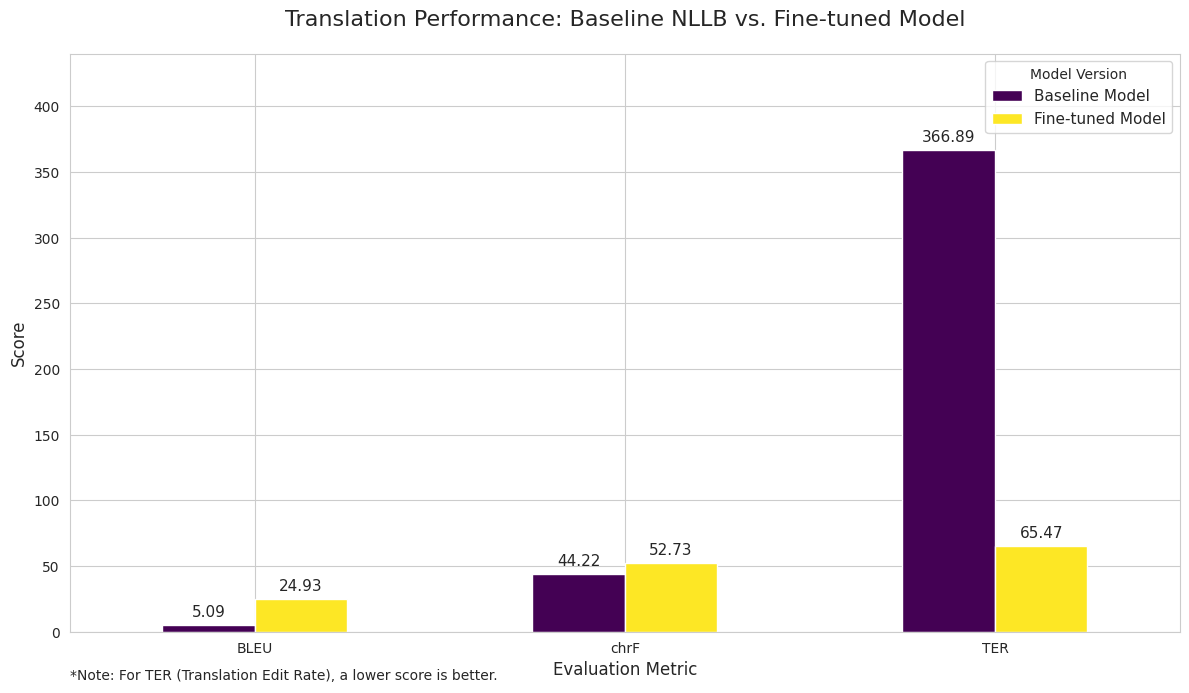

In [ ]:
# --- Plotting ---
sns.set_style("whitegrid")
ax = df.plot(kind='bar', figsize=(12, 7), colormap='viridis', rot=0)

# Add titles and labels
plt.title('Translation Performance: Baseline NLLB vs. Fine-tuned Model', fontsize=16, pad=20)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylim(0, max(df.max()) * 1.2) # Set y-axis limit to be 20% higher than the max score

# Add text labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=11)

# Add a note about TER
plt.text(-0.5, -max(df.max())*0.1, '*Note: For TER (Translation Edit Rate), a lower score is better.', fontsize=10, ha='left')


plt.legend(title='Model Version', fontsize=11)
plt.tight_layout()
plt.show()

## Visualization 2: Training Progress Line Chart

To show the model's learning progress during the fine-tuning epochs.

In [ ]:
# The trainer object from fine-tuning script holds the history
log_history = trainer.state.log_history

# Filter for evaluation logs (which contain the metrics)
eval_logs = [log for log in log_history if 'eval_loss' in log]

# Convert to a pandas DataFrame
df_logs = pd.DataFrame(eval_logs)

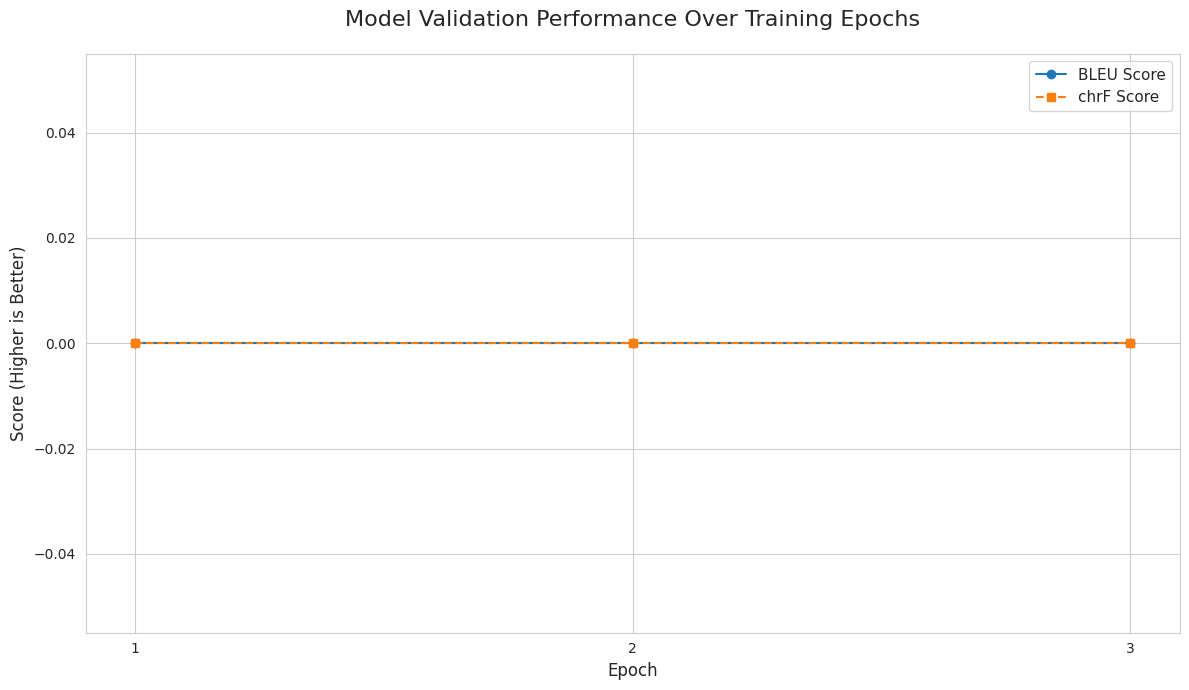

In [ ]:
# --- Plotting ---
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Plot BLEU, chrF, and TER scores over epochs
plt.plot(df_logs['epoch'], df_logs['eval_bleu'], marker='o', linestyle='-', label='BLEU Score')
plt.plot(df_logs['epoch'], df_logs['eval_chrf'], marker='s', linestyle='--', label='chrF Score')
# Since TER is an error rate (lower is better), we don't plot it on the same upward-trending graph
# as it can be confusing. We focus on the improvement metrics.

plt.title('Model Validation Performance Over Training Epochs', fontsize=16, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Score (Higher is Better)', fontsize=12)
plt.xticks(df_logs['epoch']) # Ensure ticks are exactly on the epoch numbers
plt.legend(fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

## Visualization 3: Side-by-Side Qualitative Comparison Table

To qualitatively compare actual translation examples.

In [ ]:
# Select a few interesting examples from your test set results
num_examples = 5
sample_indices = [0, 1, 2, 3, 4] # Or choose specific indices you found interesting

# Create a list of dictionaries to hold the data
comparison_data = []
for i in sample_indices:
    comparison_data.append({
        "Source (Odia)": test_odia_sentences[i],
        "Reference (German)": test_german_references[0][i],
        "Baseline NLLB Output": decoded_baseline_preds[i],
        "Fine-tuned Output": decoded_finetuned_preds[i]
    })

# Create a pandas DataFrame
df_comparison = pd.DataFrame(comparison_data)

In [ ]:
# To display the DataFrame nicely in Colab, you can just have it as the last line in a cell
print("Qualitative Comparison of Translation Examples")
display(df_comparison)

Qualitative Comparison of Translation Examples


,Source (Odia),Reference (German),Baseline NLLB Output,Fine-tuned Output
0,,,Das ist nicht wahr. . . . . . . . . . . . . . ...,
1,,,Das ist nicht wahr. . . . . . . . . . . . . . ...,
2,ପ୍ରଧାନମନ୍ତ୍ରୀ ଆବାସ ଯୋଜନା (ଗ୍ରାମୀଣ) ସହିତ ଜଡିତ ଏ...,Eine vielversprechende Nachricht im Zusammenha...,Eine Erleichterung im Zusammenhang mit der PM ...,Eine Erleichterungsnachricht im Zusammenhang m...
3,"ମଶା, ମାଛିକୁ ପକ୍ଷଯୁକ୍ତ କୀଟ ଏବଂ ଫ୍ଲି, ଉକୁଣୀ ଏବଂ ...","Mücken und Fliegen sind geflügelte Insekten, F...","Muscheln, Fliegen, Wurzeln und Bugs gehören zu...","Zu Mücken, Fliegen gehörten Feindlose Insekten..."
4,"ଏକ ସଦ୍ୟତମ ସର୍ଭେରୁ ଜଣାପଡ଼ିଛି ଯେ, ଆମ ରାଜ୍ୟରେ କ୍ୟ...","Eine aktuelle Umfrage zeigt, dass die Zahl der...","Eine aktuelle Umfrage zeigt, dass die Zahl der...","Eine aktuelle Umfrage hat gezeigt, dass die Za..."
